# **Image Mapping**



## Step 1: Install & Import Libraries

In [9]:
!pip install opencv-python-headless tensorflow matplotlib numpy pillow -q

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from PIL import Image
from google.colab import files
import io

print('OpenCV version:', cv2.__version__)
print('TF version:', tf.__version__)

OpenCV version: 4.13.0
TF version: 2.20.0


## Step 2: Upload Your Images


Upload Image 1 (source image):


Saving WhatsApp Image 2026-06-16 at 9.15.52 AM.jpeg to WhatsApp Image 2026-06-16 at 9.15.52 AM (3).jpeg
Upload Image 2 (destination/reference image):


Saving WhatsApp Image 2026-06-16 at 9.15.52 AM (1).jpeg to WhatsApp Image 2026-06-16 at 9.15.52 AM (1) (2).jpeg


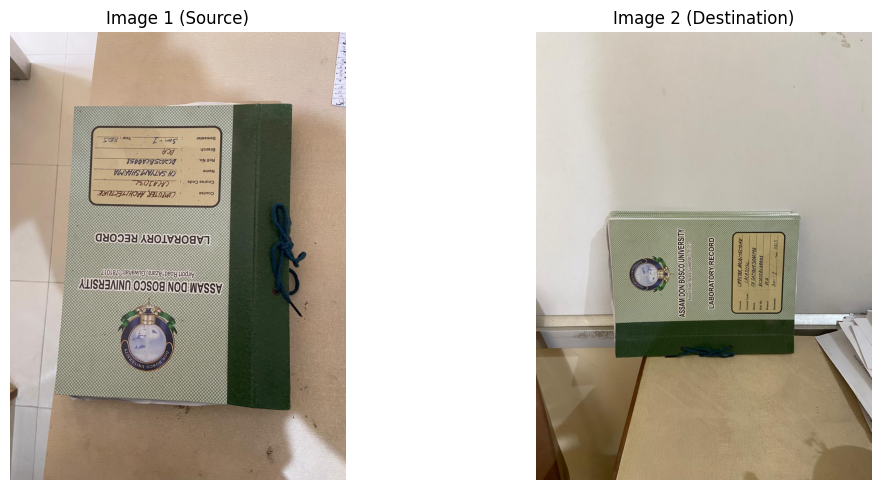

In [16]:
print('Upload Image 1 (source image):')
up1 = files.upload()
img1_name = list(up1.keys())[0]
img1 = cv2.imdecode(np.frombuffer(up1[img1_name], np.uint8), cv2.IMREAD_COLOR)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

print('Upload Image 2 (destination/reference image):')
up2 = files.upload()
img2_name = list(up2.keys())[0]
img2 = cv2.imdecode(np.frombuffer(up2[img2_name], np.uint8), cv2.IMREAD_COLOR)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img1_rgb); ax1.set_title('Image 1 (Source)', fontsize=12); ax1.axis('off')
ax2.imshow(img2_rgb); ax2.set_title('Image 2 (Destination)', fontsize=12); ax2.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Detect Keypoints with ORB

ORB (Oriented FAST and Rotated BRIEF) detects distinctive points in an image called **keypoints**, and describes each one with a binary feature vector called a **descriptor**.

Keypoints in Image 1: 1000
Keypoints in Image 2: 1000


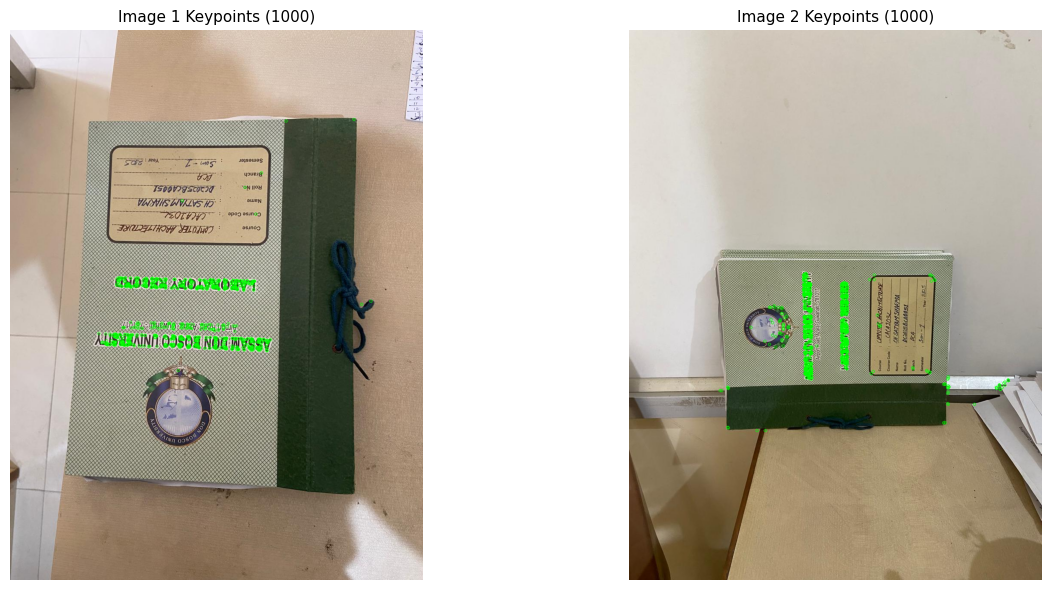

In [17]:
# Convert to grayscale for keypoint detection
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Create ORB detector
orb = cv2.ORB_create(nfeatures=1000)

kp1, desc1 = orb.detectAndCompute(gray1, None)
kp2, desc2 = orb.detectAndCompute(gray2, None)

print(f'Keypoints in Image 1: {len(kp1)}')
print(f'Keypoints in Image 2: {len(kp2)}')

# Draw keypoints
kp_img1 = cv2.drawKeypoints(img1_rgb, kp1, None, color=(0,255,0), flags=0)
kp_img2 = cv2.drawKeypoints(img2_rgb, kp2, None, color=(0,255,0), flags=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(kp_img1); ax1.set_title(f'Image 1 Keypoints ({len(kp1)})', fontsize=11); ax1.axis('off')
ax2.imshow(kp_img2); ax2.set_title(f'Image 2 Keypoints ({len(kp2)})', fontsize=11); ax2.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Match Keypoints Between Images

Total matches: 343
Good matches kept: 50


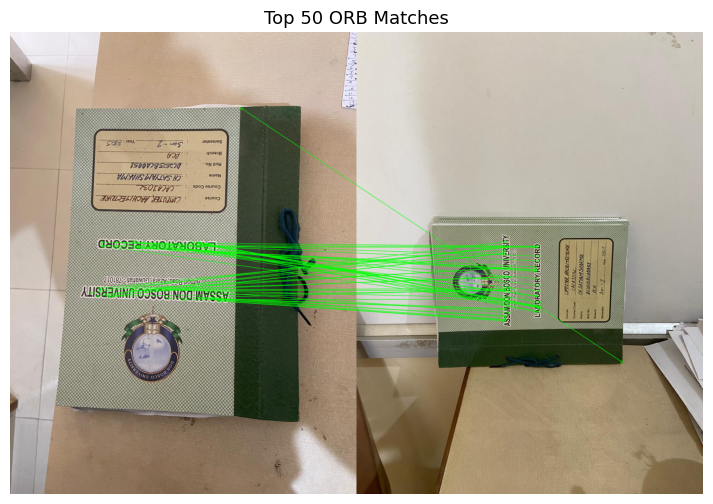

In [18]:
# BFMatcher with Hamming distance (suitable for ORB binary descriptors)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(desc1, desc2)

# Sort matches by distance (lower = better)
matches = sorted(matches, key=lambda x: x.distance)
good_matches = matches[:50]  # Keep top 50

print(f'Total matches: {len(matches)}')
print(f'Good matches kept: {len(good_matches)}')

# Draw top matches
match_img = cv2.drawMatches(
    img1_rgb, kp1, img2_rgb, kp2, good_matches, None,
    matchColor=(0,255,0), singlePointColor=None, flags=2
)

plt.figure(figsize=(16, 6))
plt.imshow(match_img)
plt.title(f'Top {len(good_matches)} ORB Matches', fontsize=13)
plt.axis('off')
plt.show()

## Step 5: Compute Homography with RANSAC

A **homography** is a 3×3 matrix that maps points from one image plane to another. RANSAC (Random Sample Consensus) makes the estimate robust to incorrect (outlier) matches.

In [19]:
# Extract point coordinates from good matches
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

# Compute homography using RANSAC
H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

inliers = mask.ravel().sum()
print(f'Homography matrix H:')
print(np.round(H, 4))
print(f'\nInlier matches (used for H): {inliers}/{len(good_matches)}')

Homography matrix H:
[[ 1.160000e-01 -6.770000e-01  9.168211e+02]
 [ 8.341000e-01  9.770000e-02  3.827654e+02]
 [ 2.000000e-04  1.000000e-04  1.000000e+00]]

Inlier matches (used for H): 45/50


## Step 6: Warp Image 1 onto Image 2's Perspective

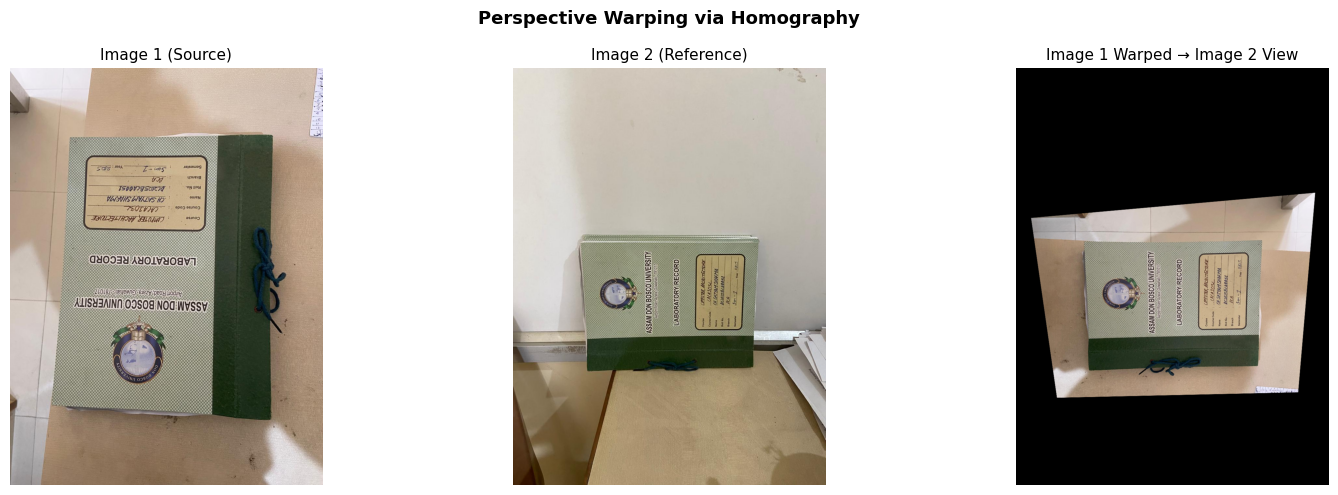

In [20]:
h, w = img2.shape[:2]
warped = cv2.warpPerspective(img1_rgb, H, (w, h))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img1_rgb); axes[0].set_title('Image 1 (Source)', fontsize=11); axes[0].axis('off')
axes[1].imshow(img2_rgb); axes[1].set_title('Image 2 (Reference)', fontsize=11); axes[1].axis('off')
axes[2].imshow(warped); axes[2].set_title('Image 1 Warped → Image 2 View', fontsize=11); axes[2].axis('off')
plt.suptitle('Perspective Warping via Homography', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()